# Practice Appendix B — TensorFlow + Keras

PyTorch 학습 파이프라인을 같은 데이터·같은 모델로 **TensorFlow / Keras** 에서 재현하는 부록. 추상화 레벨이 다른 두 가지 접근 (`tf.GradientTape` 수동 루프 vs `model.fit()` 고수준 API) 을 병렬로 제시합니다.

| 섹션 | 내용 |
|------|------|
| 1 | 데이터 준비 — Digits 60/20/20 분할 + 표준화, `tf.data.Dataset` |
| 2 | 방법 A — `tf.GradientTape` 수동 훈련 루프 |
| 3 | 방법 B — `model.compile` + `model.fit` 고수준 API |
| 4 | PyTorch ↔ TF 매핑표 |
| 5 | 테스트 세트 평가 + Confusion Matrix |
| 6 | Optimization / Regularization 기법의 TF 대응 |


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 재현성을 위한 시드 고정
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"Keras     : {keras.__version__}")

TensorFlow: 2.21.0
Keras     : 3.14.1


---
## 1. 데이터 준비 (P11과 동일)

Digits 데이터 (1797개 샘플, 8x8 손글씨, 10클래스)를 60% / 20% / 20% 로 분할하고,
**훈련 세트 통계** ($\mu, \sigma$) 로 표준화합니다.

표준화 식:
$$x^{\text{new}}_i = \frac{x_i - \mu_i}{\sigma_i}$$


In [2]:
# Digits 데이터 로드
digits = load_digits()
X, y = digits.data, digits.target  # (1797, 64), (1797,)

# 60% / 20% / 20% 분할 (stratify로 클래스 비율 유지)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

# 표준화 — train 통계 기준
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0) + 1e-8

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

# TF 기본 dtype에 맞게 캐스팅
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)
y_train = y_train.astype(np.int64)
y_val   = y_val.astype(np.int64)
y_test  = y_test.astype(np.int64)

print(f"Train: {X_train.shape},  Val: {X_val.shape},  Test: {X_test.shape}")

Train: (1077, 64),  Val: (360, 64),  Test: (360, 64)


### tf.data.Dataset — PyTorch DataLoader와 같은 역할

| PyTorch | TensorFlow |
|---|---|
| `TensorDataset(X, y)` + `DataLoader(...)` | `tf.data.Dataset.from_tensor_slices((X, y))` 후 `.shuffle(...).batch(...)` |
| `shuffle=True` | `.shuffle(buffer_size, seed=...)` |
| `batch_size=16` | `.batch(16)` |


In [3]:
batch_size = 16

# tf.data.Dataset: from_tensor_slices로 (X, y) 묶고, shuffle + batch
train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(buffer_size=1024, seed=42)
            .batch(batch_size))
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

# 한 배치 확인
for xb, yb in train_ds.take(1):
    print(f"Batch X shape: {xb.shape}")
    print(f"Batch y shape: {yb.shape}")
    print(f"Batch y[:10] : {yb[:10].numpy()}")

# epoch당 batch 수
n_batches_per_epoch = (len(X_train) + batch_size - 1) // batch_size
print(f"\nTotal batches per epoch: {n_batches_per_epoch}")

Batch X shape: (16, 64)
Batch y shape: (16,)
Batch y[:10] : [3 9 3 6 3 5 0 0 7 6]

Total batches per epoch: 68


---
## 2. 방법 A — 수동 훈련 루프 (`tf.GradientTape`)

P11의 PyTorch 수동 루프와 **1:1 대응**됩니다.

| PyTorch | TensorFlow |
|---|---|
| `optimizer.zero_grad()` | (자동 — `with tf.GradientTape()` 진입 시점 기준) |
| `output = model(x)`<br>`loss = criterion(output, y)` | `with tf.GradientTape() as tape:`<br>&nbsp;&nbsp;&nbsp;&nbsp;`logits = model(x)`<br>&nbsp;&nbsp;&nbsp;&nbsp;`loss = loss_fn(y, logits)` |
| `loss.backward()` | `grads = tape.gradient(loss, model.trainable_variables)` |
| `optimizer.step()` | `optimizer.apply_gradients(zip(grads, model.trainable_variables))` |

**구조의 차이**

- PyTorch: `loss.backward()`가 각 텐서의 `.grad`를 채우고 → `optimizer.step()`이 그걸 읽어 갱신 (2단계)
- TF: `tape.gradient()`가 기울기를 **명시적으로 반환** → `apply_gradients()`가 받아 갱신 (1단계)

**인자 순서 주의**

- PyTorch: `criterion(pred, target)` — 예측이 먼저
- Keras: `loss_fn(y_true, y_pred)` — **정답이 먼저** (위 표 참고)


In [4]:
# 모델 정의 — P11의 nn.Sequential과 동일 구조 (64 → 128 → 64 → 10)
# 출력층은 logits를 그대로 (softmax는 loss에서 처리, PyTorch CrossEntropyLoss와 같은 방식)
tf.random.set_seed(42)
model_a = keras.Sequential([
    keras.Input(shape=(64,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10),  # logits
])
model_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Loss와 Optimizer
# SparseCategoricalCrossentropy(from_logits=True) = nn.CrossEntropyLoss()
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = keras.optimizers.Adam(learning_rate=0.001)

print(f"Loss     : {loss_fn.name}")
print(f"Optimizer: Adam (lr=0.001)")

Loss     : sparse_categorical_crossentropy
Optimizer: Adam (lr=0.001)


In [6]:
# 수동 훈련 + 검증 루프
num_epochs = 50
history_a = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(num_epochs):
    # ========== 훈련 ==========
    train_loss_sum, train_correct, train_total = 0.0, 0, 0
    for X_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            # forward — training=True는 PyTorch의 model.train()에 해당
            logits = model_a(X_batch, training=True)
            loss = loss_fn(y_batch, logits)
        # backward + step
        grads = tape.gradient(loss, model_a.trainable_variables)
        optimizer.apply_gradients(zip(grads, model_a.trainable_variables))

        # 기록
        bs = int(X_batch.shape[0])
        train_loss_sum += float(loss) * bs
        preds = tf.argmax(logits, axis=1, output_type=tf.int64)
        train_correct += int(tf.reduce_sum(tf.cast(preds == y_batch, tf.int32)))
        train_total += bs

    # ========== 검증 ==========
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    for X_batch, y_batch in val_ds:
        # training=False는 PyTorch의 model.eval()에 해당 (BatchNorm/Dropout 평가 모드)
        logits = model_a(X_batch, training=False)
        loss = loss_fn(y_batch, logits)
        bs = int(X_batch.shape[0])
        val_loss_sum += float(loss) * bs
        preds = tf.argmax(logits, axis=1, output_type=tf.int64)
        val_correct += int(tf.reduce_sum(tf.cast(preds == y_batch, tf.int32)))
        val_total += bs

    history_a['train_loss'].append(train_loss_sum / train_total)
    history_a['val_loss'].append(val_loss_sum / val_total)
    history_a['train_acc'].append(train_correct / train_total)
    history_a['val_acc'].append(val_correct / val_total)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs}  "
              f"Train Loss: {history_a['train_loss'][-1]:.4f}  Acc: {history_a['train_acc'][-1]:.3f}  |  "
              f"Val Loss: {history_a['val_loss'][-1]:.4f}  Acc: {history_a['val_acc'][-1]:.3f}")

print("\nTraining (Method A) finished.")

Epoch  10/50  Train Loss: 0.0127  Acc: 0.999  |  Val Loss: 126493.2554  Acc: 0.969


Epoch  20/50  Train Loss: 0.0022  Acc: 1.000  |  Val Loss: 146763.0426  Acc: 0.969


Epoch  30/50  Train Loss: 0.0008  Acc: 1.000  |  Val Loss: 158733.2404  Acc: 0.972


Epoch  40/50  Train Loss: 0.0004  Acc: 1.000  |  Val Loss: 169478.0609  Acc: 0.975


Epoch  50/50  Train Loss: 0.0002  Acc: 1.000  |  Val Loss: 178223.7262  Acc: 0.978

Training (Method A) finished.


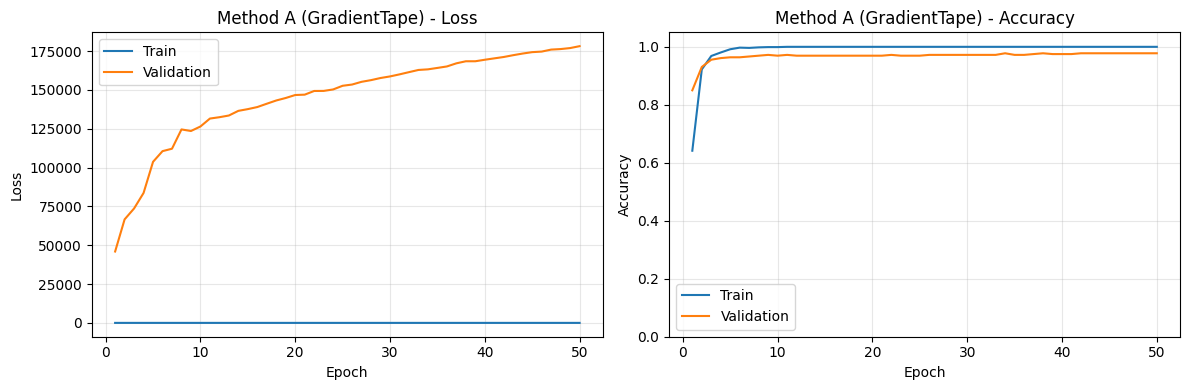

In [7]:
# 학습 곡선 시각화 — 방법 A
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep_range = range(1, num_epochs + 1)

axes[0].plot(ep_range, history_a['train_loss'], label='Train')
axes[0].plot(ep_range, history_a['val_loss'],   label='Validation')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Method A (GradientTape) - Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history_a['train_acc'], label='Train')
axes[1].plot(ep_range, history_a['val_acc'],   label='Validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Method A (GradientTape) - Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout(); plt.show()

---
## 3. 방법 B — 고수준 API (`model.compile` + `model.fit`)

방법 A의 30여 줄짜리 훈련 루프를 **두 줄** (`compile` + `fit`) 로 줄입니다.
배치 순회 / GradientTape / `apply_gradients` / 메트릭 누적 / train·eval 모드 전환이 전부 `.fit()` 내부에서 자동 처리됩니다.

| 방법 A에서 손으로 짜던 것 | `.fit()` 내부에서 자동 처리 |
|---|---|
| `for X_batch, y_batch in train_ds:` | 자동 배치 순회 |
| `with tf.GradientTape() as tape:` ... `tape.gradient(...)` | 자동 |
| `optimizer.apply_gradients(...)` | 자동 |
| `model(x, training=True/False)` 모드 전환 | 자동 |
| accuracy 누적 계산 | `metrics=['accuracy']` 로 지정만 |
| epoch별 평균 loss/acc 기록 | 반환되는 `History` 객체에 자동 저장 |

같은 모델·같은 데이터·같은 하이퍼파라미터로 학습하면, 방법 A와 거의 동일한 결과가 나옵니다.
(시드를 고정해도 내부 연산 순서 차이로 완전히 같지는 않을 수 있음)


In [8]:
# 모델 정의 — 방법 A와 동일 구조 (가중치 초기화부터 새로)
tf.random.set_seed(42)
model_b = keras.Sequential([
    keras.Input(shape=(64,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10),
])

# compile — loss / optimizer / metrics를 한 번에 등록
model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
)

# fit — 학습 한 줄로
history_b_obj = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    verbose=2,  # epoch당 한 줄 출력
)

# 결과 dict 변환 (방법 A와 같은 키 이름으로)
history_b = {
    'train_loss': history_b_obj.history['loss'],
    'val_loss':   history_b_obj.history['val_loss'],
    'train_acc':  history_b_obj.history['accuracy'],
    'val_acc':    history_b_obj.history['val_accuracy'],
}

Epoch 1/50


68/68 - 0s - 6ms/step - accuracy: 0.7103 - loss: 1.2640 - val_accuracy: 0.8917 - val_loss: 33515.2617


Epoch 2/50


68/68 - 0s - 961us/step - accuracy: 0.9424 - loss: 0.2627 - val_accuracy: 0.9472 - val_loss: 44116.4844


Epoch 3/50


...

68/68 - 0s - 952us/step - accuracy: 1.0000 - loss: 2.2959e-04 - val_accuracy: 0.9778 - val_loss: 61958.3789


Epoch 49/50


68/68 - 0s - 928us/step - accuracy: 1.0000 - loss: 2.1623e-04 - val_accuracy: 0.9778 - val_loss: 62495.5039


Epoch 50/50


68/68 - 0s - 949us/step - accuracy: 1.0000 - loss: 2.0525e-04 - val_accuracy: 0.9778 - val_loss: 62423.8438


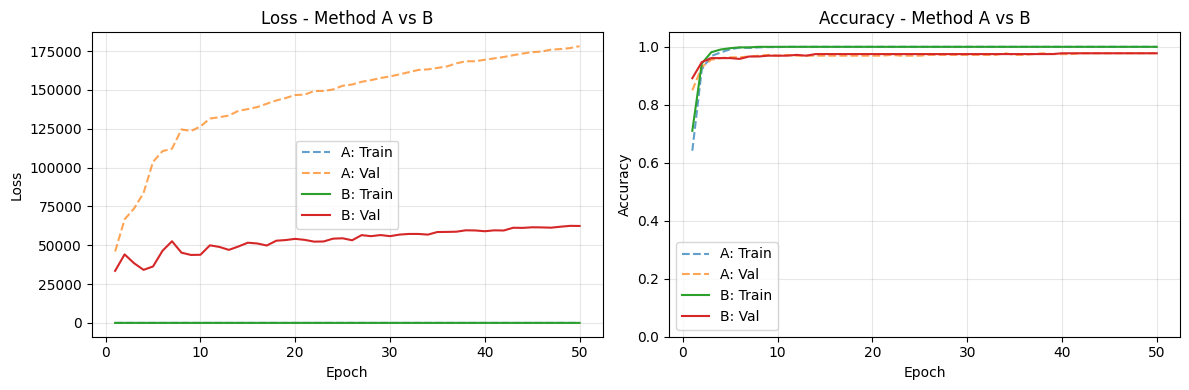

두 방법은 동일한 학습 — 추상화 레벨만 다름. 곡선이 거의 겹쳐야 정상.


In [9]:
# 학습 곡선 비교 — 방법 A (점선) vs 방법 B (실선)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep_range = range(1, 51)

axes[0].plot(ep_range, history_a['train_loss'], '--', label='A: Train', alpha=0.7)
axes[0].plot(ep_range, history_a['val_loss'],   '--', label='A: Val',   alpha=0.7)
axes[0].plot(ep_range, history_b['train_loss'], '-',  label='B: Train')
axes[0].plot(ep_range, history_b['val_loss'],   '-',  label='B: Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss - Method A vs B')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, history_a['train_acc'], '--', label='A: Train', alpha=0.7)
axes[1].plot(ep_range, history_a['val_acc'],   '--', label='A: Val',   alpha=0.7)
axes[1].plot(ep_range, history_b['train_acc'], '-',  label='B: Train')
axes[1].plot(ep_range, history_b['val_acc'],   '-',  label='B: Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy - Method A vs B')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)

plt.tight_layout(); plt.show()
print("두 방법은 동일한 학습 — 추상화 레벨만 다름. 곡선이 거의 겹쳐야 정상.")

---
## 4. PyTorch ↔ TensorFlow 매핑표

본 노트북·.

### 모델 정의

| PyTorch | TensorFlow / Keras |
|---|---|
| `nn.Sequential(...)` | `keras.Sequential([...])` |
| `nn.Linear(in, out)` | `keras.layers.Dense(out)` (입력 크기는 자동 추론) |
| `nn.ReLU()` | `keras.layers.Activation('relu')` 또는 `Dense(..., activation='relu')` |
| `model.parameters()` | `model.trainable_variables` |

### 데이터 파이프라인

| PyTorch | TensorFlow |
|---|---|
| `torch.FloatTensor(X)` | `tf.constant(X, dtype=tf.float32)` |
| `TensorDataset(X, y)` | `tf.data.Dataset.from_tensor_slices((X, y))` |
| `DataLoader(ds, batch_size=16, shuffle=True)` | `ds.shuffle(buffer_size).batch(16)` |

### 손실 함수

| PyTorch | TensorFlow |
|---|---|
| `nn.CrossEntropyLoss()` (logits + int labels) | `SparseCategoricalCrossentropy(from_logits=True)` |
| `nn.BCEWithLogitsLoss()` | `BinaryCrossentropy(from_logits=True)` |
| `nn.MSELoss()` | `MeanSquaredError()` |

### 옵티마이저

| PyTorch | TensorFlow |
|---|---|
| `torch.optim.SGD(params, lr=0.01)` | `keras.optimizers.SGD(learning_rate=0.01)` |
| `torch.optim.Adam(params, lr=0.001)` | `keras.optimizers.Adam(learning_rate=0.001)` |

### 훈련 루프 핵심

| PyTorch (수동) | TF GradientTape (수동, 방법 A) | Keras `.fit()` (방법 B) |
|---|---|---|
| `model.train()` | `model(x, training=True)` | 자동 |
| `output = model(x)` | `with tf.GradientTape() as tape: logits = model(x)` | 자동 |
| `loss = criterion(output, y)` | `loss = loss_fn(y, logits)` *(인자 순서 주의)* | `compile(loss=...)` |
| `optimizer.zero_grad()` | (`with` 진입 시 자동) | 자동 |
| `loss.backward()` | `grads = tape.gradient(loss, model.trainable_variables)` | 자동 |
| `optimizer.step()` | `optimizer.apply_gradients(zip(grads, vars))` | 자동 |
| `model.eval()` + `with torch.no_grad():` | `model(x, training=False)` | 자동 |


---
## 5. 테스트 세트 평가

방법 B의 모델로 test set 정확도와 confusion matrix를 확인합니다.
`model.evaluate()`는 `compile`에 등록된 loss/metrics를 자동 계산하고,
`model.predict()`는 logits를 그대로 반환합니다 (softmax는 적용되지 않은 상태).


Test Loss    : 65918.3047
Test Accuracy: 0.9889


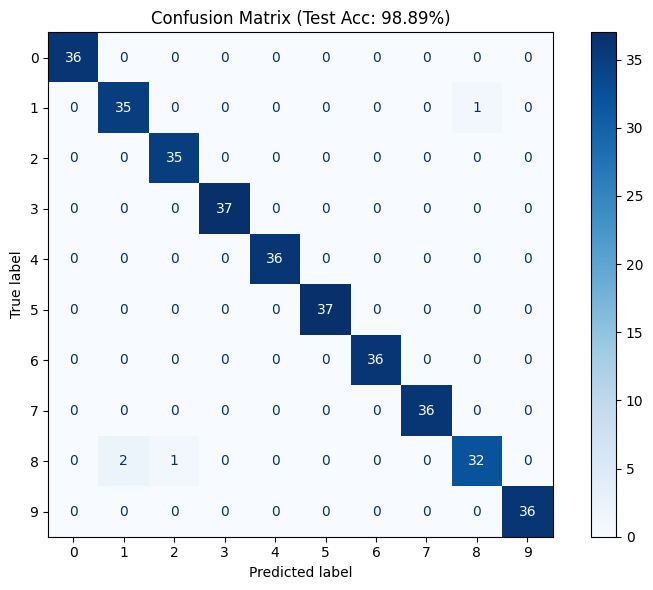

In [10]:
# evaluate — compile에 등록된 loss / accuracy 자동 계산
test_loss, test_acc = model_b.evaluate(test_ds, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# predict — logits 반환 (softmax 미적용). argmax로 클래스 결정
y_test_logits = model_b.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_logits, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=digits.target_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix (Test Acc: {test_acc:.2%})')
plt.tight_layout(); plt.show()

---
## 6. Optimization / Regularization 기법의 TF 대응

Optimization ·Regularization 에서 다룬 학습 동역학·정규화 기법의 TF 대응.
실행 코드 없이 매핑만 — 같은 개념을 두 진영에서 어떻게 표현하는지 확인용.

### 가중치 초기화

| PyTorch | Keras |
|---|---|
| `nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')` | `Dense(..., kernel_initializer='he_normal')` |
| `nn.init.xavier_normal_(layer.weight)` | `Dense(..., kernel_initializer='glorot_normal')` |

### 옵티마이저 · 활성함수 · 배치 정규화

| PyTorch | Keras |
|---|---|
| `torch.optim.SGD(...)` / `Adam(...)` | `keras.optimizers.SGD(...)` / `Adam(...)` |
| `nn.Sigmoid()` / `nn.ReLU()` | `activation='sigmoid'` / `activation='relu'` |
| `nn.BatchNorm1d(features)` | `keras.layers.BatchNormalization()` |

### 정규화

| PyTorch | Keras |
|---|---|
| `optim.Adam(..., weight_decay=1e-4)` (L2) | `Dense(..., kernel_regularizer=keras.regularizers.l2(1e-4))` |
| 수동 L1 항 추가 | `Dense(..., kernel_regularizer=keras.regularizers.l1(1e-4))` |
| `nn.Dropout(p=0.3)` | `keras.layers.Dropout(0.3)` |


---
## 마무리

이 노트북에서 본 두 방식은 사실 **추상화 레벨이 다른 같은 학습**입니다.

- **방법 A (`tf.GradientTape`)** — 직접 기울기를 받아 가중치를 갱신, 학습의 모든 단계가 코드로 보임
- **방법 B (`model.fit`)** — 같은 학습을 `compile` + `fit` 두 줄로

PyTorch Lightning 의 `Trainer.fit()` 과 본 노트북의 Keras `model.fit()` 은 거의 같은 패턴입니다 —
즉 "수동 루프 vs `.fit()`" 은 TF만의 특성이 아니라 두 진영 모두에서 볼 수 있는 wrapper 디자인입니다.

|  | 수동 루프 | `.fit()` 스타일 |
|---|---|---|
| **PyTorch** | PyTorch 수동 루프 | PyTorch Lightning |
| **TensorFlow** | 본 노트북 §2 (방법 A) | 본 노트북 §3 (방법 B) |

> 학습 시점에서 train loop를 직접 손으로 짜본 경험이 중요한 이유는, 그래야 `.fit()` 같은 한 줄짜리 추상화가 "안에서 무엇을 하는지" 이해된 채로 사용되기 때문입니다.
